# Spring-mass-dampener with spikes

Demonstrates how individual spikes act on the plant through the B matrix, with no
feedback. Spikes are placed by hand at fixed timesteps: neuron 1 fires (positive
push) at two early steps, neuron 2 fires (the second actuator direction) once
later. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
A = np.array([
    [0.0, 1],            # position rate = 1 * velocity
    [-0.1, -0.1]         # velocity rate = stiffness + damping
])

B = np.array([        # spike-to-force map  
    [0.0, 0.0],
    [2.0, -2.0]       # N1 spikes velocity with +2 and N2 spikes velocity with -2
])

def smd_dynamics(t, x, s):
    return A @ x + B @ s
    
T = 100                  # total simulated time (s)
dt = 0.01                # output sampling step
steps = int(T/dt)

x = np.zeros((2, steps))
x[:,0] = [0,0]           # initial state

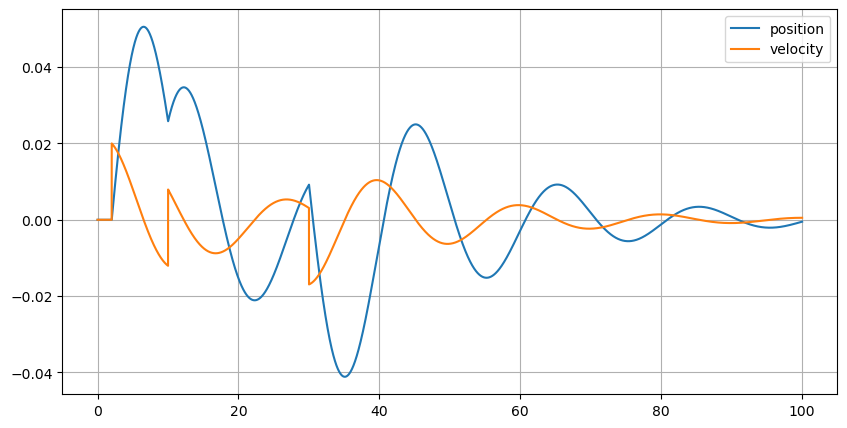

In [3]:
for i in range(steps-1):
    s = np.array([0,0])              # default: no spike
    if i == 200 or i == 1000:
        s = np.array([1,0])          # neuron 1 fires (push +2 on velocity)
    if i == 3000:
        s = np.array([0,1])          # neuron 2 fires (push -2 on velocity)
    dx = A @ x[:,i] + B @ s
    x[:,i+1] = x[:,i] + dt * dx

t = np.arange(steps) * dt

plt.figure(figsize=(10,5))
plt.plot(t, x[0], label="position")
plt.plot(t, x[1], label="velocity")
plt.legend()
plt.grid()
plt.show()